# Downscaling U10 with multiple predictors

In [1]:
# Training model with original dimensions
import xarray as xr
import numpy as np
import ecubevis as ecv
import scipy as sp
import netCDF4 as nc
import os
import shutil
import csv
import pandas as pd
import torch_dl4ds as dds
import torch as pt

In [2]:
!python --version
#Should be Python 3.11.13

Python 3.11.13


In [3]:
uwrf_train = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_train.nc')
uwrf_val = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_val.nc')
uwrf_test = xr.open_dataset('/D4/data/gvaillant/uwrf-split/uwrf_test.nc')
# --------
nam_train = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_train.nc')
nam_val = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_val.nc')
nam_test = xr.open_dataset('/D4/data/gvaillant/nam-split/nam_test.nc')

In [4]:
uwrf_train

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (time, y, x) float32 155MB ...
    longitude  (time, y, x) float32 155MB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB ...
    PSFC       (time, y, x) float32 155MB ...
    U10        (time, y, x) float32 155MB ...
    V10        (time, y, x) float32 155MB ...
    SWDOWN     (time, y, x) float32 155MB ...
    PBLH       (time, y, x) float32 155MB ...
    HGT        (time, y, x) float32 155MB ...
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

In [5]:
#FOR uWRF just make the latitude and longitude values only have y and x as the dimensions instead of time,y, x because at every time step it is the same

uwrf_train['latitude'] = uwrf_train['latitude'].isel(time=0)
uwrf_val['latitude'] = uwrf_val['latitude'].isel(time=0)
uwrf_test['latitude'] = uwrf_test['latitude'].isel(time=0)
#--
uwrf_train['longitude'] = uwrf_train['longitude'].isel(time=0)
uwrf_val['longitude'] = uwrf_val['longitude'].isel(time=0)
uwrf_test['longitude'] = uwrf_test['longitude'].isel(time=0)

In [6]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'


for ds in nam_list:

            # Calculate wind direction
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_direction = (np.arctan2(-u, -v) * 180 / np.pi + 360) % 360

            # Add wind speed as a new variable to the dataset
            ds['WD'] = (('time', 'y', 'x'), wind_direction)
            ds['WD'].attrs['units'] = 'degrees'
            ds['WD'].attrs['description'] = '10-meter wind direction (from which blowing)'

In [7]:
uwrf_list = [uwrf_train, uwrf_val, uwrf_test]
nam_list = [nam_train, nam_val, nam_test]

for ds in uwrf_list: 
            
            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'


for ds in nam_list:

            # Calculate wind speed
            u = ds['U10'].data  # Extract data as numpy array
            v = ds['V10'].data  # Extract data as numpy array
            wind_speed = np.sqrt(u**2 + v**2)

            # Add wind speed as a new variable to the dataset
            ds['WS'] = (('time', 'y', 'x'), wind_speed)
            ds['WS'].attrs['units'] = 'm/s'
            ds['WS'].attrs['description'] = 'Calculated wind speed from U10 and V10'

# Cyclical Time of Day

In [8]:
def encode_time_of_day(time_array):
    time_array = pd.DatetimeIndex(time_array)
    seconds_in_day = 24 * 60 * 60
    time_seconds = (
        time_array.hour * 3600 +
        time_array.minute * 60 +
        time_array.second
    )
    sin_time = np.sin(2 * np.pi * time_seconds / seconds_in_day)
    cos_time = np.cos(2 * np.pi * time_seconds / seconds_in_day)
    return sin_time, cos_time
    

############UWRF TRAIN########################################
sin_time, cos_time = encode_time_of_day(uwrf_train.time.values)
uwrf_train = uwrf_train.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############UWRF VAL##########################################
sin_time, cos_time = encode_time_of_day(uwrf_val.time.values)
uwrf_val = uwrf_val.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############UWRF TEST##########################################
sin_time, cos_time = encode_time_of_day(uwrf_test.time.values)
uwrf_test = uwrf_test.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############NAM TRAIN##########################################
sin_time, cos_time = encode_time_of_day(nam_train.time.values)
nam_train = nam_train.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############NAM VAL##########################################
sin_time, cos_time = encode_time_of_day(nam_val.time.values)
nam_val = nam_val.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)
#############NAM TEST##########################################
sin_time, cos_time = encode_time_of_day(nam_test.time.values)
nam_test = nam_test.assign(
    sin_time=("time", sin_time),
    cos_time=("time", cos_time)
)


In [9]:
def add_circular_time_features(ds):
    # Encode time as sin/cos
    sin_time, cos_time = encode_time_of_day(ds.time.values)

    # Convert to NumPy arrays explicitly
    sin_time = np.asarray(sin_time)
    cos_time = np.asarray(cos_time)

    # Get dimensions
    t_len = ds.sizes["time"]
    y_len = ds.sizes["y"]
    x_len = ds.sizes["x"]

    # Broadcast from (time,) -> (time, y, x)
    sin_broadcasted = np.broadcast_to(sin_time[:, None, None], (t_len, y_len, x_len))
    cos_broadcasted = np.broadcast_to(cos_time[:, None, None], (t_len, y_len, x_len))

    # Assign to dataset
    ds["sin_time"] = (("time", "y", "x"), sin_broadcasted)
    ds["cos_time"] = (("time", "y", "x"), cos_broadcasted)

    return ds


In [10]:
uwrf_train = add_circular_time_features(uwrf_train)
uwrf_val = add_circular_time_features(uwrf_val)
uwrf_test = add_circular_time_features(uwrf_test)

nam_train = add_circular_time_features(nam_train)
nam_val = add_circular_time_features(nam_val)
nam_test = add_circular_time_features(nam_test)


In [11]:
uwrf_train

<xarray.Dataset> Size: 2GB
Dimensions:    (time: 2697, y: 120, x: 120)
Coordinates:
    latitude   (y, x) float32 58kB ...
    longitude  (y, x) float32 58kB ...
  * time       (time) datetime64[ns] 22kB 2019-01-01 ... 2019-04-14T03:00:00
Dimensions without coordinates: y, x
Data variables:
    T2         (time, y, x) float32 155MB ...
    PSFC       (time, y, x) float32 155MB ...
    U10        (time, y, x) float32 155MB -1.981 -2.044 -2.099 ... 1.553 1.525
    V10        (time, y, x) float32 155MB 2.25 2.206 2.152 ... 3.783 1.914 1.966
    SWDOWN     (time, y, x) float32 155MB ...
    PBLH       (time, y, x) float32 155MB ...
    HGT        (time, y, x) float32 155MB ...
    WD         (time, y, x) float32 155MB 138.6 137.2 135.7 ... 219.1 217.8
    WS         (time, y, x) float32 155MB 2.998 3.007 3.007 ... 4.63 2.465 2.488
    sin_time   (time, y, x) float64 311MB 0.0 0.0 0.0 ... 0.7071 0.7071 0.7071
    cos_time   (time, y, x) float64 311MB 1.0 1.0 1.0 ... 0.7071 0.7071 0.7071
Attributes: (12/119)
    TITLE:                            OUTPUT FROM WRF V3.9 MODEL
    START_DATE:                      2019-01-01_00:00:00
    SIMULATION_START_DATE:           2019-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION:        121
    SOUTH-NORTH_GRID_DIMENSION:      121
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    ISLAKE:                          -1
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      -1
    ETAC:                            0.0

# Main training code



Here you can run multiple trainings trying different combinations of predictor variables and architectures.

Running model with backbone=resnet, filters=4, blocks=4, epochs=75


Epoch 1/75, Train Loss: 0.5925, Val Loss: 0.2319


Epoch 2/75, Train Loss: 0.2318, Val Loss: 0.1549


Epoch 3/75, Train Loss: 0.1752, Val Loss: 0.1348


Epoch 4/75, Train Loss: 0.1588, Val Loss: 0.1275


...

Epoch 71/75, Train Loss: 0.0998, Val Loss: 0.0768


Epoch 72/75, Train Loss: 0.0998, Val Loss: 0.0668


Epoch 73/75, Train Loss: 0.0997, Val Loss: 0.0655


Epoch 74/75, Train Loss: 0.0989, Val Loss: 0.0637


Epoch 75/75, Train Loss: 0.1004, Val Loss: 0.0732
Total runtime: 1h 35m 48s
Plot saved to: /home/gvaillant1/downscaling/pretrained-models/U10/U10-Other-Models/learning_curve.png


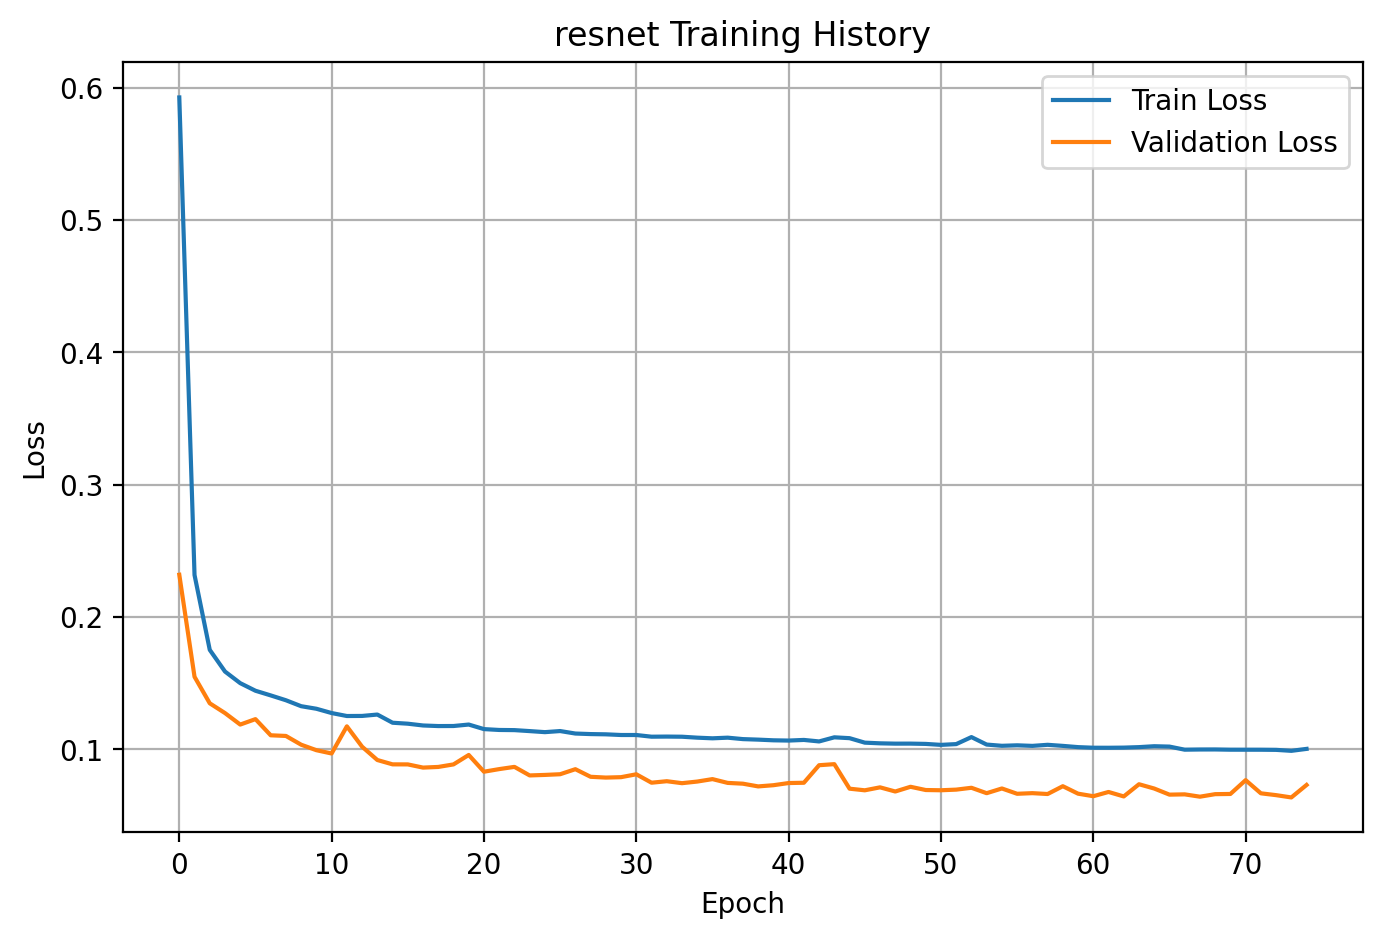

GPU logger was not initialized.
Running model with backbone=resnet, filters=4, blocks=8, epochs=75


Epoch 1/75, Train Loss: 0.7681, Val Loss: 0.7516


Epoch 2/75, Train Loss: 0.5970, Val Loss: 0.4522


Epoch 3/75, Train Loss: 0.3574, Val Loss: 0.3735


Epoch 4/75, Train Loss: 0.2513, Val Loss: 0.1558


...

Epoch 37/75, Train Loss: 0.1064, Val Loss: 0.0746


Epoch 38/75, Train Loss: 0.1050, Val Loss: 0.0835


Epoch 39/75, Train Loss: 0.1062, Val Loss: 0.0736


Epoch 40/75, Train Loss: 0.1063, Val Loss: 0.0888


Epoch 41/75, Train Loss: 0.1030, Val Loss: 0.0703
Early stopping triggered.
Total runtime: 1h 36m 35s
Plot saved to: /home/gvaillant1/downscaling/pretrained-models/U10/U10-Other-Models/learning_curve.png


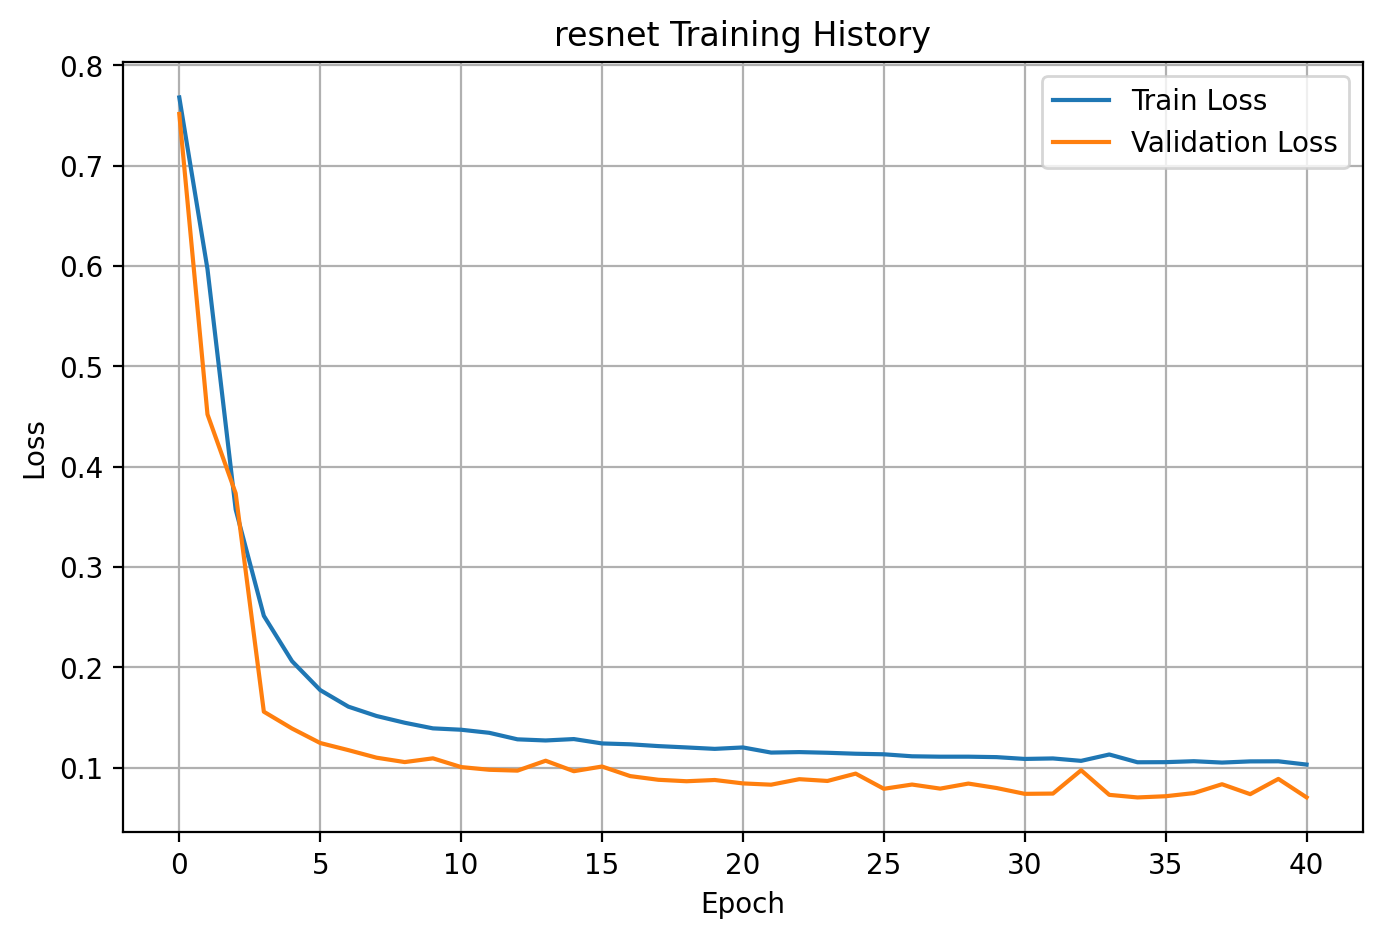

GPU logger was not initialized.
Running model with backbone=resnet, filters=8, blocks=4, epochs=75


Epoch 1/75, Train Loss: 0.5099, Val Loss: 0.2472


Epoch 2/75, Train Loss: 0.1862, Val Loss: 0.1387


Epoch 3/75, Train Loss: 0.1514, Val Loss: 0.1394


Epoch 4/75, Train Loss: 0.1387, Val Loss: 0.1167


...

Epoch 56/75, Train Loss: 0.0842, Val Loss: 0.0598


Epoch 57/75, Train Loss: 0.0824, Val Loss: 0.0538


Epoch 58/75, Train Loss: 0.0822, Val Loss: 0.0578


Epoch 59/75, Train Loss: 0.0816, Val Loss: 0.0555


Epoch 60/75 [Training]:  71%|█████████████▍     | 60/85 [01:56<00:46,  1.87s/it]

In [ ]:
########################
## DOWNSCALING U10 ##
########################

var_list = ['U10']
pred_var_list = ['PSFC', 'T2', 'V10', 'PBLH']

for var in var_list:
    # High resolution (uWRF) data
    var_hr_train = uwrf_train[var]
    var_hr_val = uwrf_val[var]
    var_hr_test = uwrf_test[var]

    # Combine predictor variables
    pred_var_hr_train = np.stack([uwrf_train[p] for p in pred_var_list], axis=1)
    pred_var_hr_val = np.stack([uwrf_val[p] for p in pred_var_list], axis=1)
    pred_var_hr_test = np.stack([uwrf_test[p] for p in pred_var_list], axis=1)

    # Low resolution (NAM) data
    var_lr_train = nam_train[var]
    var_lr_val = nam_val[var]
    var_lr_test = nam_test[var]
    
    #Combine LR predictor variables
    pred_var_lr_train = np.stack([nam_train[p] for p in pred_var_list], axis=1)
    pred_var_lr_val = np.stack([nam_val[p] for p in pred_var_list], axis=1)
    pred_var_lr_test = np.stack([nam_test[p] for p in pred_var_list], axis=1)

    # Normalize
    var_scaler_train = dds.TorchStandardScaler(axis=None)
    var_scaler_train.fit(var_hr_train)

    pred_var_scaler_train = dds.TorchStandardScaler(axis=None)
    pred_var_scaler_train.fit(pred_var_hr_train)

    # High resolution (targets)
    y_train = var_scaler_train.transform(var_hr_train)
    y_val = var_scaler_train.transform(var_hr_val)
    y_test = var_scaler_train.transform(var_hr_test)

    # Low resolution (inputs)
    x_train = var_scaler_train.transform(var_lr_train)
    x_val = var_scaler_train.transform(var_lr_val)
    x_test = var_scaler_train.transform(var_lr_test)

    y_train = np.expand_dims(y_train, axis=1)
    y_val = np.expand_dims(y_val, axis=1)
    y_test = np.expand_dims(y_test, axis=1)


    x_train = np.expand_dims(x_train, axis=1)
    x_val = np.expand_dims(x_val, axis=1)
    x_test = np.expand_dims(x_test, axis=1)

    # Create one scaler per predictor channel
    pred_var_scalers = []
    x_z_train_list, x_z_val_list, x_z_test_list = [], [], []
    y_z_train_list, y_z_val_list, y_z_test_list = [], [], []
    
    for i in range(pred_var_hr_train.shape[1]):
        scaler = dds.TorchStandardScaler(axis=None)
        scaler.fit(pred_var_hr_train[:, i])
        pred_var_scalers.append(scaler)
    
        y_z_train_list.append(np.expand_dims(scaler.transform(pred_var_hr_train[:, i]), axis=1))
        y_z_val_list.append(np.expand_dims(scaler.transform(pred_var_hr_val[:, i]), axis=1))
        y_z_test_list.append(np.expand_dims(scaler.transform(pred_var_hr_test[:, i]), axis=1))
    
        x_z_train_list.append(np.expand_dims(scaler.transform(pred_var_lr_train[:, i]), axis=1))
        x_z_val_list.append(np.expand_dims(scaler.transform(pred_var_lr_val[:, i]), axis=1))
        x_z_test_list.append(np.expand_dims(scaler.transform(pred_var_lr_test[:, i]), axis=1))
    
    # Concatenate all predictor channels along channel axis
    pred_var_train = np.concatenate(y_z_train_list, axis=1)
    pred_var_val = np.concatenate(y_z_val_list, axis=1)
    pred_var_test = np.concatenate(y_z_test_list, axis=1)

    
    #pred_var_train = [y_z_train]
    #pred_var_val = [y_z_val]
    #pred_var_test = [y_z_test]

    # Paths and file setup
    best_model_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Best-Model"
    other_models_path = f"/home/gvaillant1/downscaling/pretrained-models/{var}/{var}-Other-Models"
    csv_file = f"/home/gvaillant1/downscaling/results/{var}_torch_model_results.csv"
    results = pd.read_csv(csv_file) if os.path.exists(csv_file) else pd.DataFrame()

    # Model uniqueness tracking
    existing_model_ids = set()
    if not results.empty:
        for _, row in results.iterrows():
            model_id_row = (
                row["Downscaled Variable"],
                row["Predictor"],
                row["Backbone"],
                str(row["Filters"]),
                str(row["Blocks"]),
                str(row["Learning Rate"]),
                row["Interpolation Method"],
                row["Upsampling Method"],
                row["Batch Size"],
                str(row["Epochs"]),
                row["Loss Function"],
                str(row["Early Stopping"]),
                str(row["Conv Block"]),
                str(row["Device"])
            )
            existing_model_ids.add(model_id_row)

    # Loss tracking for early stopping
    min_losses = {}
    if not results.empty:
        for loss_fn in results['Loss Function'].unique():
            vals = results[results['Loss Function'] == loss_fn]['Test Loss'].astype(float)
            if not vals.empty:
                min_losses[loss_fn] = vals.min()

    for backbone in ['resnet']:
        for filters in [4, 8]:
            for blocks in [4, 8]:
                for epoch in [75]:
                    ARCH_PARAMS = dict(
                        n_filters=filters,
                        n_blocks=blocks,
                        normalization=None,
                        dropout_rate=0.5,
                        dropout_variant='spatial',
                        attention=False,
                        activation='relu',
                        localcon_layer=True
                    )

                    print(f"Running model with backbone={backbone}, filters={filters}, blocks={blocks}, epochs={epoch}")

                    trainer = dds.TorchSupervisedTrainer(
                        backbone=backbone,
                        upsampling='spc',
                        data_train=y_train,
                        data_val=y_val,
                        data_test=y_test,
                        scale=3,
                        predictors_train=[pred_var_train],
                        predictors_val=[pred_var_val],
                        predictors_test=[pred_var_test],
                        interpolation='inter_area',
                        batch_size=32,
                        loss='mae',
                        epochs=epoch,
                        steps_per_epoch=None,
                        validation_steps=None,
                        test_steps=None,
                        learning_rate=1e-3,
                        lr_decay_after=1e4,
                        early_stopping=True,
                        patience=6,
                        min_delta=0,
                        save=False,
                        save_bestmodel=False,
                        save_path=other_models_path,
                        show_plot=True,
                        verbose=True,
                        device='CPU',
                        **ARCH_PARAMS)

                    model_id = (
                        var,
                        "NULL" if trainer.predictors_train is None else '+'.join(pred_var_list),
                        backbone,
                        str(filters),
                        str(blocks),
                        str(trainer.learning_rate),
                        trainer.interpolation,
                        trainer.upsampling,
                        trainer.batch_size,
                        str(trainer.epochs),
                        trainer.loss,
                        str(trainer.early_stopping),
                        str(ARCH_PARAMS["localcon_layer"]),
                        str(trainer.device)
                    )

                    if model_id in existing_model_ids:
                        print("Match found! Skipping training for:", model_id)
                        continue

                    trainer.run()

                    val_loss = trainer.val_loss if hasattr(trainer, "val_loss") else float("inf")
                    training_runtime = trainer.training_runtime if hasattr(trainer, "training_runtime") else "NULL"

                    # Always save to "Other Models" first
                    os.makedirs(other_models_path, exist_ok=True)
                    model_filename = f"{var.lower()}_model.pth"
                    model_file_path = os.path.join(other_models_path, model_filename)
                    pt.save(trainer.model.state_dict(), model_file_path)

                    # If this is the best model so far (per loss function), copy to "Best Model"
                    if trainer.loss not in min_losses or val_loss < min_losses[trainer.loss]:
                        min_losses[trainer.loss] = val_loss
                        os.makedirs(best_model_path, exist_ok=True)
                        shutil.copy(model_file_path, os.path.join(best_model_path, model_filename))
                        model_save_path = best_model_path
                        print("Copied to best model directory")
                    else:
                        model_save_path = other_models_path

                    # Log result
                    new_result = pd.DataFrame([[
                        var,
                        "NULL" if trainer.predictors_train is None else '+'.join(pred_var_list),
                        round(val_loss, 4),
                        backbone,
                        filters,
                        blocks,
                        trainer.epochs,
                        sum(p.numel() for p in trainer.model.parameters() if p.requires_grad),
                        trainer.upsampling,
                        trainer.interpolation,
                        trainer.batch_size,
                        trainer.learning_rate,
                        trainer.loss,
                        trainer.early_stopping,
                        training_runtime,
                        model_save_path,
                        ARCH_PARAMS["localcon_layer"],
                        trainer.device
                    ]], columns=[
                        "Downscaled Variable", "Predictor", "Test Loss",
                        "Backbone", "Filters", "Blocks",
                        "Epochs", "Parameters", "Upsampling Method",
                        "Interpolation Method", "Batch Size", "Learning Rate",
                        "Loss Function", "Early Stopping", "Training Runtime", "Model Path", "Conv Block", "Device"
                    ])

                    # Append the new result to CSV immediately
                    if os.path.exists(csv_file):
                        new_result.to_csv(csv_file, mode='a', index=False, header=False)
                    else:
                        new_result.to_csv(csv_file, mode='w', index=False, header=True)
                    
                    # Reload CSV so next model can compare against updated results
                    results = pd.read_csv(csv_file)

    print("Training complete!")
